<h1>Image segmentation<span class="tocSkip"></span></h1>
<div class="toc"><ul class="toc-item"></ul></div>

In [112]:
import numpy as np
import torch
from torch import nn
import torchvision
import torchvision.models as models
from torchvision.transforms import v2

import matplotlib.pyplot as plt
import matplotlib.patches as patches
from PIL import Image

In [80]:
model = models.resnet152(weights='DEFAULT')

Downloading: "https://download.pytorch.org/models/resnet152-f82ba261.pth" to /Users/alexfil/.cache/torch/hub/checkpoints/resnet152-f82ba261.pth
100%|████████████████████████████████████████| 230M/230M [00:22<00:00, 10.6MB/s]


In [81]:
img = Image.open ('/Users/alexfil/Desktop/TRANSFER/segmentation/1.jpg')

# Получаю преобразования для изображения и список классов.
transforms = models.ResNet34_Weights.DEFAULT.transforms()
class_names = models.ResNet34_Weights.DEFAULT.meta['categories']

In [82]:
transforms

ImageClassification(
    crop_size=[224]
    resize_size=[256]
    mean=[0.485, 0.456, 0.406]
    std=[0.229, 0.224, 0.225]
    interpolation=InterpolationMode.BILINEAR
)

In [83]:
class_names[:5]

['tench', 'goldfish', 'great white shark', 'tiger shark', 'hammerhead']

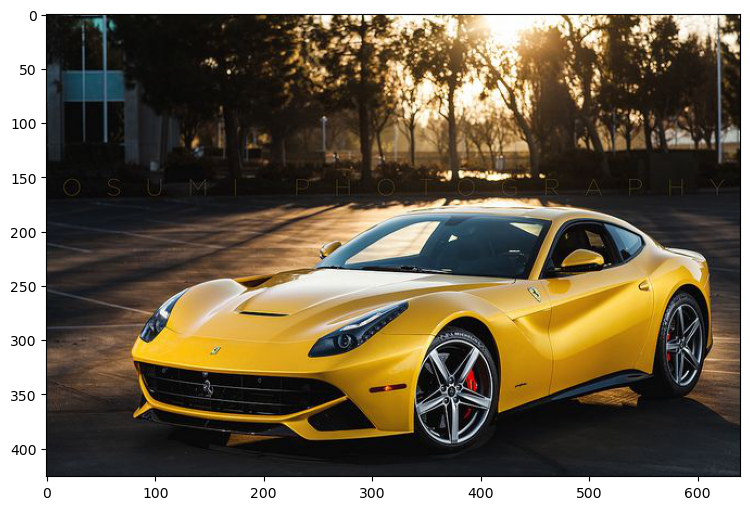

Индекс предсказанного класса: 817


In [84]:
plt.imshow(img)
plt.show()

model.eval()
img_in = transforms(img).unsqueeze(dim=0)
pred = model(img_in).squeeze()

sorted_, indices = pred.softmax(dim=0).sort(descending=True)
print(f'Индекс предсказанного класса: {indices[0]}')

In [85]:
new_model = nn.Sequential(
    model.conv1,
    model.bn1, 
    model.relu, 
    model.maxpool, 
    model.layer1, 
    model.layer2, 
    model.layer3,
    model.layer4
)

In [86]:
# Весовые коэффициенты соответствующие предсказанному классу.
weights = model.fc.state_dict()['weight'][indices[0]]

weights.shape

torch.Size([2048])

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers).


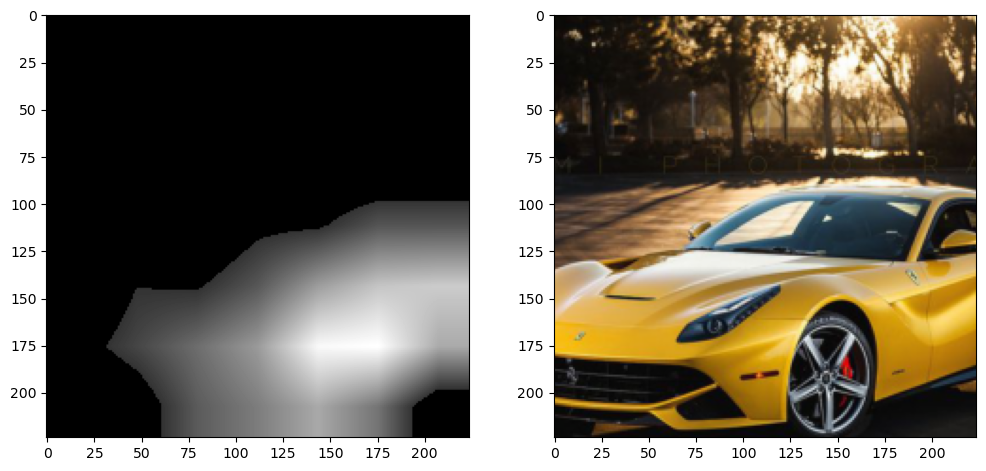

In [87]:
# Переводим модель в режим поелсказания
new_model.eval()

# Преобразуем изображение, что бы его можно было подать на вход модели.
img_in = transforms(img).unsqueeze(dim=0) # img_in -> (1, 3, 224, 224)

# Получаем карты признаков.
feature_maps = new_model(img_in)

# Карты признаков умножаем на соответствующие им веса.
pred = feature_maps * weights.reshape((feature_maps.shape[1], 1, 1)) # pred - > (1, 512, 7, 7)

# Сумируем карты признаков.
pred = pred.sum(dim=1, keepdim=True) # pred -› (1, 1, 7, 7)

img_numpy = nn.Upsample(
    scale_factor=32, 
    mode= 'bilinear')(pred).squeeze().detach().numpy()

# Оставляем значения, которые больше 20% от максимального. Остальные = 0
mask = img_numpy > img_numpy.max () * 0.2
img_numpy = img_numpy * mask

# Преборазуем исходное изображение для сравнения.
img1 = transforms(img)
img1 = np.transpose(
    img1,
    axes=[1, 2, 0]
) * np.array([[[0.229, 0.224, 0.225111]]]) + np.array([[[0.485, 0.456, 0.406111]]])

plt.rcParams['figure.figsize'] = [12, 6]
plt.subplot(1, 2, 1) 
plt.imshow(img_numpy, cmap='gray') 
plt.subplot(1, 2, 2) 
plt.imshow(img1)

In [90]:
y2 = np.where(img_numpy.any(axis=1) == True)

In [91]:
y2

(array([ 99, 100, 101, 102, 103, 104, 105, 106, 107, 108, 109, 110, 111,
        112, 113, 114, 115, 116, 117, 118, 119, 120, 121, 122, 123, 124,
        125, 126, 127, 128, 129, 130, 131, 132, 133, 134, 135, 136, 137,
        138, 139, 140, 141, 142, 143, 144, 145, 146, 147, 148, 149, 150,
        151, 152, 153, 154, 155, 156, 157, 158, 159, 160, 161, 162, 163,
        164, 165, 166, 167, 168, 169, 170, 171, 172, 173, 174, 175, 176,
        177, 178, 179, 180, 181, 182, 183, 184, 185, 186, 187, 188, 189,
        190, 191, 192, 193, 194, 195, 196, 197, 198, 199, 200, 201, 202,
        203, 204, 205, 206, 207, 208, 209, 210, 211, 212, 213, 214, 215,
        216, 217, 218, 219, 220, 221, 222, 223]),)

In [92]:
y2 = np.where(img_numpy.any(axis=1) == True)[0][-1]

In [93]:
y2

223

In [94]:
y1 = np.where(img_numpy.any(axis=1) == True)[0][0]

In [95]:
y1

99

In [96]:
np.where(img_numpy.any(axis=0) == True)

(array([ 32,  33,  34,  35,  36,  37,  38,  39,  40,  41,  42,  43,  44,
         45,  46,  47,  48,  49,  50,  51,  52,  53,  54,  55,  56,  57,
         58,  59,  60,  61,  62,  63,  64,  65,  66,  67,  68,  69,  70,
         71,  72,  73,  74,  75,  76,  77,  78,  79,  80,  81,  82,  83,
         84,  85,  86,  87,  88,  89,  90,  91,  92,  93,  94,  95,  96,
         97,  98,  99, 100, 101, 102, 103, 104, 105, 106, 107, 108, 109,
        110, 111, 112, 113, 114, 115, 116, 117, 118, 119, 120, 121, 122,
        123, 124, 125, 126, 127, 128, 129, 130, 131, 132, 133, 134, 135,
        136, 137, 138, 139, 140, 141, 142, 143, 144, 145, 146, 147, 148,
        149, 150, 151, 152, 153, 154, 155, 156, 157, 158, 159, 160, 161,
        162, 163, 164, 165, 166, 167, 168, 169, 170, 171, 172, 173, 174,
        175, 176, 177, 178, 179, 180, 181, 182, 183, 184, 185, 186, 187,
        188, 189, 190, 191, 192, 193, 194, 195, 196, 197, 198, 199, 200,
        201, 202, 203, 204, 205, 206, 207, 208, 209

In [97]:
x2 = np.where(img_numpy.any(axis=0) == True)[0][-1]

In [98]:
x2

223

In [99]:
x1 = np.where(img_numpy.any(axis=0) == True)[0][0]

In [100]:
x1

32

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers).


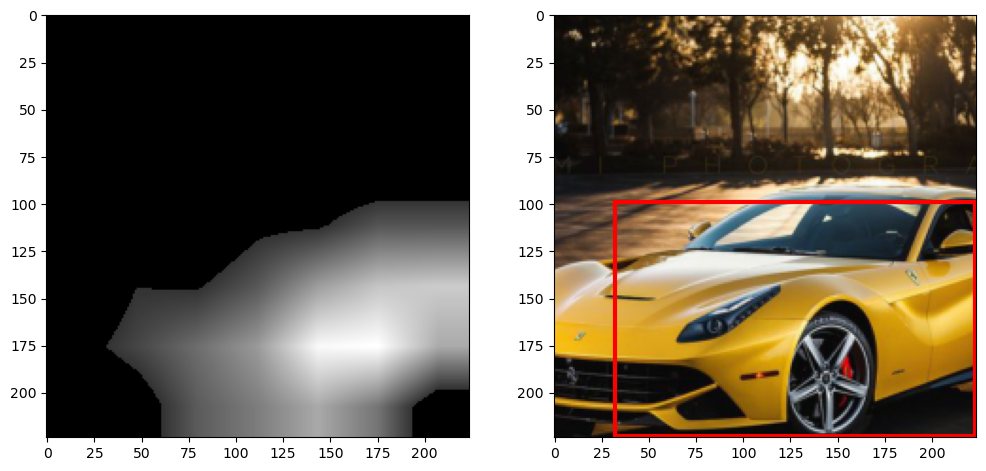

In [118]:
plt.rcParams['figure.figsize'] = [12, 6]
plt.subplot(1, 2, 1) 
plt.imshow(img_numpy, cmap='gray')
plt.subplot(1, 2, 2)
plt.imshow(img1)
ax = plt.gca()
rect = patches.Rectangle(
    (x1, y1), 
    (x2 - x1), 
    (y2 - y1), 
    linewidth=3, 
    edgecolor='red', 
    fill=False
)
ax.add_patch(rect)
pass